<a href="https://colab.research.google.com/github/NotfromEQ/Step_Up/blob/Training_Model_Playground/Try_ImageClassiffication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Digits Prediction

ลองฝึกใช้ ImageClassification

Import Tool

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# เช็คว่าใช้ GPU ได้ไหม
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Data Loading

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# โหลดข้อมูล MNIST
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 457kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.14MB/s]


Simple CNN

In [16]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # ออก 10 คลาส (เลข 0-9)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

model = SimpleNet().to(device)

Loss & Optimizer

In [17]:
criterion = nn.CrossEntropyLoss() # วัดว่าทายผิดแค่ไหน
optimizer = optim.Adam(model.parameters(), lr=0.001) # ตัวปรับจูนน้ำหนัก AI

Training Loop

In [18]:
model.train()
for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)

    optimizer.zero_grad()    # ล้างค่าเก่า
    output = model(data)     # ให้ AI ทาย
    loss = criterion(output, target) # ดูว่าทายผิดเท่าไหร่
    loss.backward()          # คำนวณทิศทางที่จะปรับ
    optimizer.step()         # ปรับค่าพลัง (Weights)

    if batch_idx % 100 == 0:
        print(f'Train Step: [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():.6f}')

Train Step: [0/60000] Loss: 2.300035
Train Step: [6400/60000] Loss: 0.323247
Train Step: [12800/60000] Loss: 0.225951
Train Step: [19200/60000] Loss: 0.314460
Train Step: [25600/60000] Loss: 0.099872
Train Step: [32000/60000] Loss: 0.197023
Train Step: [38400/60000] Loss: 0.078270
Train Step: [44800/60000] Loss: 0.157568
Train Step: [51200/60000] Loss: 0.059942
Train Step: [57600/60000] Loss: 0.175141


ลองให้ Ai ทายรูป

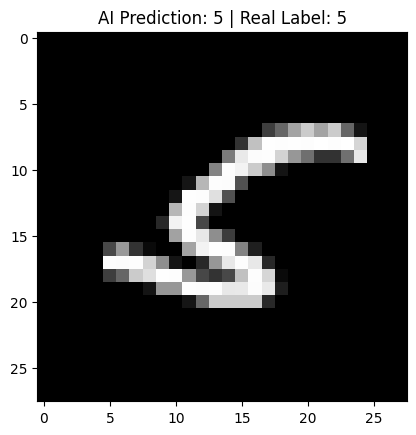

In [19]:
import matplotlib.pyplot as plt

model.eval() # เปลี่ยนเป็นโหมด "ใช้งาน" (ไม่ต้องเรียนรู้แล้ว)
dataiter = iter(train_loader)
images, labels = next(dataiter)

# ให้ AI ทายรูปแรกจาก Batch
with torch.no_grad():
    output = model(images[0].to(device))
    prediction = output.argmax(dim=1).item()

# แสดงรูปและคำตอบ
plt.imshow(images[0].numpy().squeeze(), cmap='gray')
plt.title(f'AI Prediction: {prediction} | Real Label: {labels[0]}')
plt.show()

Ai ทายลายมือคน -> MNIST (Modified National Institute of Standards and Technology)

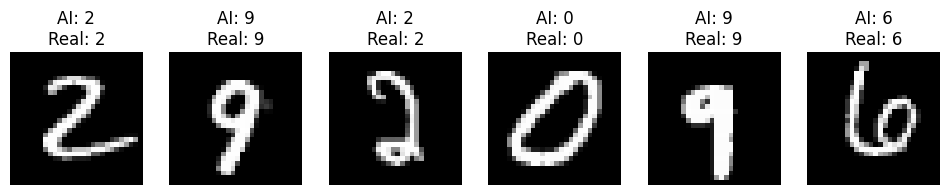

In [21]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(train_loader))

fig = plt.figure(figsize=(12, 4))
for i in range(6):
    with torch.no_grad():
        output = model(images[i].to(device))
        pred = output.argmax(dim=1).item()

    ax = fig.add_subplot(1, 6, i+1)
    ax.imshow(images[i].numpy().squeeze(), cmap='gray')
    ax.set_title(f"AI: {pred}\nReal: {labels[i]}")
    ax.axis('off')
plt.show()